<a href="https://colab.research.google.com/github/simsekergun/WGeffectiveIndex/blob/main/WG_n_eff_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from io import BytesIO
import requests

In [2]:
url = "https://raw.githubusercontent.com/simsekergun/WGeffectiveIndex/main/training_data.mat"

response = requests.get(url)
data = loadmat(BytesIO(response.content))

# Replace 'training_data' with the actual variable name in the .mat file
df1 = pd.DataFrame(
    data['training_data'],
    columns=[
        'lambda_um',
        'width_um',
        'height_um',
        'n_eff_TE',
        'n_eff_TM'
    ]
)

In [3]:
url = "https://raw.githubusercontent.com/simsekergun/WGeffectiveIndex/main/testing_data.mat"

response = requests.get(url)
data2 = loadmat(BytesIO(response.content))

df2 = pd.DataFrame(
    data2['testing_data'],
    columns=[
        'lambda_um',
        'width_um',
        'height_um',
        'n_eff_TE',
        'n_eff_TM'
    ]
)

In [4]:
df1.head(4)

,lambda_um,width_um,height_um,n_eff_TE,n_eff_TM
0,0.75,0.75,0.600,1.917813,1.911563
1,0.75,0.75,0.625,1.921546,1.916689
2,0.75,0.75,0.650,1.924945,1.921312
3,0.75,0.75,0.675,1.928049,1.925494


In [5]:
df2.head(4)

,lambda_um,width_um,height_um,n_eff_TE,n_eff_TM
0,1.568,0.971,0.907,1.783003,1.778825
1,0.930,2.998,0.938,1.970376,1.962498
2,1.042,2.602,0.949,1.954576,1.944650
3,0.841,1.077,0.857,1.949126,1.945536


In [6]:
df1.shape, df2.shape

((57239, 5), (1000, 5))

## Linear Regression

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# df1 and df2
# lambda_um, width_um, height_um, n_eff_TE, n_eff_TM

feature_cols = ['lambda_um', 'width_um', 'height_um']
target_col = 'n_eff_TE'   # switch to 'n_eff_TM' if needed

X_train = df1[feature_cols].values
y_train = df1[target_col].values

X_test = df2[feature_cols].values
y_test = df2[target_col].values

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Test RMSE: {rmse:.6e}")
print(f"Test R^2: {r2:.6f}")

Coefficients: [-0.18296502  0.03543059  0.15263755]
Intercept: 1.9229496608227588
Test RMSE: 1.413161e-02
Test R^2: 0.933316


Linear regression is not that accurate as expected!

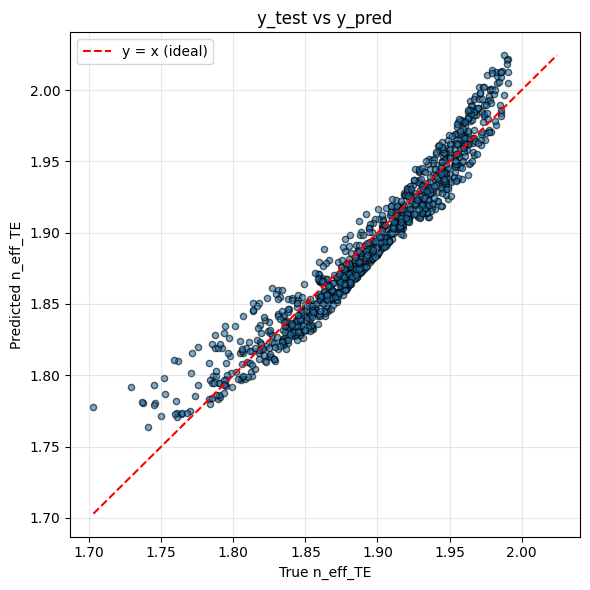

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=20)

# Add y = x reference line (perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (ideal)')

plt.xlabel('True n_eff_TE')
plt.ylabel('Predicted n_eff_TE')
plt.title('y_test vs y_pred')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fully connected neural network

Epoch 0: train_loss=1.000789e+00, val_loss=9.379244e-01
Epoch 200: train_loss=1.207217e-03, val_loss=1.107414e-03
Epoch 400: train_loss=2.740243e-04, val_loss=2.518492e-04
Epoch 600: train_loss=1.388267e-04, val_loss=1.238861e-04
Epoch 800: train_loss=9.518545e-05, val_loss=8.607959e-05
Epoch 1000: train_loss=6.817723e-05, val_loss=6.331722e-05
Epoch 1200: train_loss=5.163006e-05, val_loss=4.959643e-05
Epoch 1400: train_loss=4.187349e-05, val_loss=4.123960e-05
Epoch 1600: train_loss=3.548163e-05, val_loss=3.548741e-05
Epoch 1800: train_loss=3.103302e-05, val_loss=3.130220e-05
Epoch 2000: train_loss=2.792703e-05, val_loss=2.823625e-05
Epoch 2200: train_loss=2.572892e-05, val_loss=2.595825e-05
Epoch 2400: train_loss=2.407833e-05, val_loss=2.418845e-05
Epoch 2600: train_loss=2.272898e-05, val_loss=2.272927e-05
Epoch 2800: train_loss=2.161414e-05, val_loss=2.155904e-05
Epoch 3000: train_loss=2.064196e-05, val_loss=2.055685e-05
Epoch 3200: train_loss=1.977637e-05, val_loss=1.968428e-05
Epoc

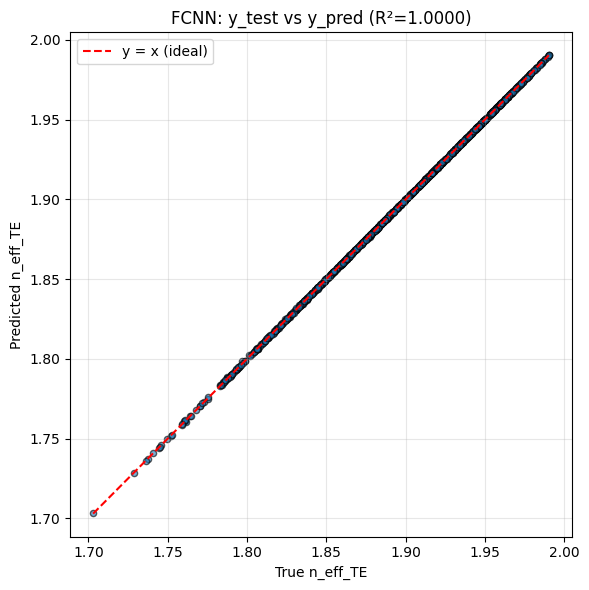

In [9]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------
# Data prep
# ---------------------------
feature_cols = ['lambda_um', 'width_um', 'height_um']
target_col = 'n_eff_TE'

X_train = df1[feature_cols].values.astype(np.float32)
y_train = df1[target_col].values.astype(np.float32).reshape(-1, 1)

X_test = df2[feature_cols].values.astype(np.float32)
y_test = df2[target_col].values.astype(np.float32).reshape(-1, 1)

# Scale inputs (NN trains much better on normalized features)
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

# Scale target too (n_eff values are ~1-3, but scaling still helps convergence)
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)
y_test_s = y_scaler.transform(y_test)

X_train_t = torch.from_numpy(X_train_s)
y_train_t = torch.from_numpy(y_train_s)
X_test_t = torch.from_numpy(X_test_s)
y_test_t = torch.from_numpy(y_test_s)

# ---------------------------
# Model
# ---------------------------
class FCNN(nn.Module):
    #def __init__(self, in_dim=3, hidden=(64, 64, 32), out_dim=1):
    def __init__(self, in_dim=3, hidden=(128, 128, 64, 32), out_dim=1):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            #layers.append(nn.ReLU())
            layers.append(nn.SiLU())
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FCNN().to(device)

criterion = nn.MSELoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=300)


X_train_t, y_train_t = X_train_t.to(device), y_train_t.to(device)
X_test_t, y_test_t = X_test_t.to(device), y_test_t.to(device)

# ---------------------------
# Training loop (with train/val split for monitoring)
# ---------------------------
n_val = int(0.01 * len(X_train_t))
perm = torch.randperm(len(X_train_t))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr, y_tr = X_train_t[tr_idx], y_train_t[tr_idx]
X_val, y_val = X_train_t[val_idx], y_train_t[val_idx]

#epochs = 3000
best_val_loss = float('inf')
best_state = None
patience_counter = 0
#early_stop_patience = 300

epochs = 8000
early_stop_patience = 800

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    pred = model(X_tr)
    loss = criterion(pred, y_tr)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter > early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: train_loss={loss.item():.6e}, val_loss={val_loss:.6e}")

model.load_state_dict(best_state)

# ---------------------------
# Evaluate on test set
# ---------------------------
model.eval()
with torch.no_grad():
    y_pred_s = model(X_test_t).cpu().numpy()

# Inverse-transform back to physical n_eff units
y_pred = y_scaler.inverse_transform(y_pred_s)
y_test_orig = y_scaler.inverse_transform(y_test_t.cpu().numpy())

mse = mean_squared_error(y_test_orig, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_pred)

print(f"\nTest RMSE: {rmse:.6e}")
print(f"Test R^2: {r2:.6f}")

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_orig, y_pred, alpha=0.6, edgecolors='k', s=20)
min_val = min(y_test_orig.min(), y_pred.min())
max_val = max(y_test_orig.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (ideal)')
plt.xlabel('True n_eff_TE')
plt.ylabel('Predicted n_eff_TE')
plt.title(f'FCNN: y_test vs y_pred (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## SVM
First, I found the optimum parameters. This step takes a very long time.

Best params: {'C': 1000, 'epsilon': 0.001, 'gamma': 0.1}
but I am going to use {'C': 100, 'epsilon': 0.01, 'gamma': 0.1}


Test RMSE: 3.701593e-04
Test R^2: 0.999954


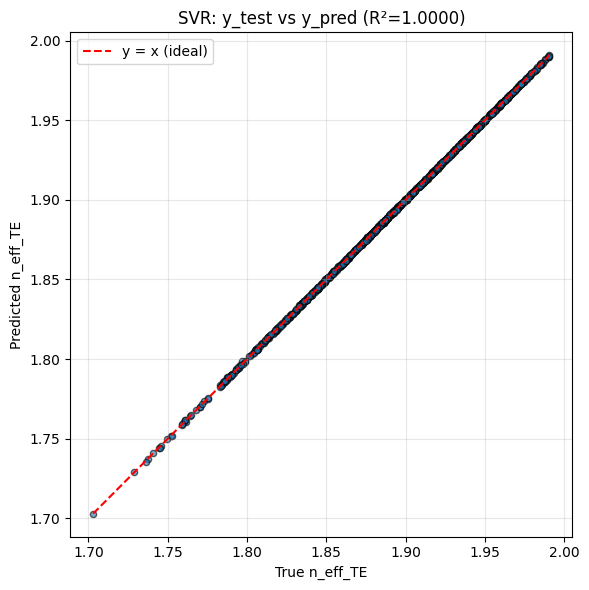

In [10]:
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ---------------------------
# Data prep
# ---------------------------
feature_cols = ['lambda_um', 'width_um', 'height_um']
target_col = 'n_eff_TE'

X_train = df1[feature_cols].values
y_train = df1[target_col].values

X_test = df2[feature_cols].values
y_test = df2[target_col].values

# SVR is scale-sensitive — scale both X and y
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

# ---------------------------
# Model + hyperparameter search
# ---------------------------
#param_grid = {
#    'C': [1, 10, 100, 1000],
#    'gamma': ['scale', 0.01, 0.1, 1],
#    'epsilon': [0.001, 0.01, 0.1]
#}

#svr = SVR(kernel='rbf')

#grid_search = GridSearchCV(
#    svr, param_grid, cv=5,
#    scoring='neg_mean_squared_error',
#    n_jobs=-1, verbose=1
#)
#grid_search.fit(X_train_s, y_train_s)

#print("Best params:", grid_search.best_params_)
#model = grid_search.best_estimator_


model = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.01
)

model.fit(X_train_s, y_train_s)

# ---------------------------
# Evaluate on test set
# ---------------------------
y_pred_s = model.predict(X_test_s)
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nTest RMSE: {rmse:.6e}")
print(f"Test R^2: {r2:.6f}")

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=20)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (ideal)')
plt.xlabel('True n_eff_TE')
plt.ylabel('Predicted n_eff_TE')
plt.title(f'SVR: y_test vs y_pred (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# highest relative error
np.max((y_test-y_pred)/y_pred)

np.float64(0.0005111327871149271)